In [28]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

import os, getpass
from dotenv import load_dotenv
load_dotenv()

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("AZURE_OPENAI_API_KEY")
_set_env("AZURE_OPENAI_ENDPOINT")



In [29]:
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient
# Define a model client. You can use other model client that implements
# the `ChatCompletionClient` interface.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)

In [30]:
# Define a simple function tool that the agent can use.
# For this example, we use a fake weather tool for demonstration purposes.
async def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is 73 degrees and Sunny."


# Define an AssistantAgent with the model, tool, system message, and reflection enabled.
# The system message instructs the agent via natural language.
agent = AssistantAgent(
    name="weather_agent",
    model_client=model_client,
    tools=[get_weather],
    system_message="You are a helpful assistant.",
    reflect_on_tool_use=True,
    model_client_stream=True,  # Enable streaming tokens from the model client.
)


# # Run the agent and stream the messages to the console.
# async def main() -> None:
#     await Console(agent.run_stream(task="What is the weather in New York?"))
#     # Close the connection to the model client.
#     await model_client.close()


# # NOTE: if running this inside a Python script you'll need to use asyncio.run(main()).
# await main()

In [31]:
# Use asyncio.run(agent.run(...)) when running in a script.
result = await agent.run(task="What is the weather in New York?")
print(result)


messages=[TextMessage(source='user', models_usage=None, metadata={}, content='What is the weather in New York?', type='TextMessage'), ToolCallRequestEvent(source='weather_agent', models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0), metadata={}, content=[FunctionCall(id='call_NH0fEhkL9BhefafKJxCBeuZU', arguments='{"city":"New York"}', name='get_weather')], type='ToolCallRequestEvent'), ToolCallExecutionEvent(source='weather_agent', models_usage=None, metadata={}, content=[FunctionExecutionResult(content='The weather in New York is 73 degrees and Sunny.', name='get_weather', call_id='call_NH0fEhkL9BhefafKJxCBeuZU', is_error=False)], type='ToolCallExecutionEvent'), TextMessage(source='weather_agent', models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0), metadata={}, content='The weather in New York is currently 73°F and sunny. Perfect for outdoor activities!', type='TextMessage')] stop_reason=None


In [32]:
for message in result.messages:
    print(message)

source='user' models_usage=None metadata={} content='What is the weather in New York?' type='TextMessage'
source='weather_agent' models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0) metadata={} content=[FunctionCall(id='call_NH0fEhkL9BhefafKJxCBeuZU', arguments='{"city":"New York"}', name='get_weather')] type='ToolCallRequestEvent'
source='weather_agent' models_usage=None metadata={} content=[FunctionExecutionResult(content='The weather in New York is 73 degrees and Sunny.', name='get_weather', call_id='call_NH0fEhkL9BhefafKJxCBeuZU', is_error=False)] type='ToolCallExecutionEvent'
source='weather_agent' models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0) metadata={} content='The weather in New York is currently 73°F and sunny. Perfect for outdoor activities!' type='TextMessage'


In [33]:
async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.run_stream(task="Find information on AutoGen"):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await Console(
        agent.run_stream(task="What is the weather in New York?"),
        output_stats=True,  # Enable stats printing.
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()


---------- TextMessage (user) ----------
What is the weather in New York?
---------- ModelClientStreamingChunkEvent (weather_agent) ----------
The weather in New York is currently 73°F and sunny.
[Prompt tokens: 0, Completion tokens: 0]
---------- Summary ----------
Number of messages: 2
Finish reason: None
Total prompt tokens: 0
Total completion tokens: 0
Duration: 2.84 seconds



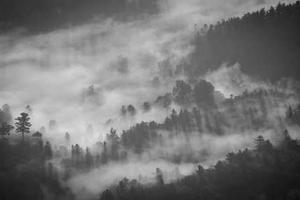

In [34]:
from io import BytesIO

import PIL
import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image

# Create a multi-modal message with random image and text.
pil_image = PIL.Image.open(BytesIO(requests.get("https://picsum.photos/300/200").content))
img = Image(pil_image)
multi_modal_message = MultiModalMessage(content=["Can you describe the content of this image?", img], source="user")
img


In [35]:
# Use asyncio.run(...) when running in a script.
result = await agent.run(task=multi_modal_message)
print(result.messages[-1].content)  # type: ignore


This image depicts a misty or foggy forest landscape in black and white. The trees are partially obscured by the fog, creating a serene and mysterious atmosphere. The light filtering through the mist highlights the silhouettes of the trees and adds depth to the scene.


In [36]:
from autogen_core.tools import FunctionTool


# Define a tool using a Python function.
async def web_search_func(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# This step is automatically performed inside the AssistantAgent if the tool is a Python function.
web_search_function_tool = FunctionTool(web_search_func, description="Find information on the web")
# The schema is provided to the model during AssistantAgent's on_messages call.
web_search_function_tool.schema


{'name': 'web_search_func',
 'description': 'Find information on the web',
 'parameters': {'type': 'object',
  'properties': {'query': {'description': 'query',
    'title': 'Query',
    'type': 'string'}},
  'required': ['query'],
  'additionalProperties': False},
 'strict': False}

In [38]:
from typing import Literal

from pydantic import BaseModel
from autogen_agentchat.messages import StructuredMessage


# The response format for the agent as a Pydantic base model.
class AgentResponse(BaseModel):
    thoughts: str
    response: Literal["happy", "sad", "neutral"]


# Create an agent that uses the OpenAI GPT-4o model.
agent = AssistantAgent(
    "assistant",
    model_client=model_client,
    system_message="Categorize the input as happy, sad, or neutral following the JSON format.",
    # Define the output content type of the agent.
    output_content_type=AgentResponse,
)

result = await Console(agent.run_stream(task="I am happy."))

# Check the last message in the result, validate its type, and print the thoughts and response.
assert isinstance(result.messages[-1], StructuredMessage)
assert isinstance(result.messages[-1].content, AgentResponse)
print("Thought: ", result.messages[-1].content.thoughts)
print("Response: ", result.messages[-1].content.response)
await model_client.close()


---------- TextMessage (user) ----------
I am happy.


---------- StructuredMessage[AgentResponse] (assistant) ----------
{"thoughts":"The user expressed happiness.","response":"happy"}
Thought:  The user expressed happiness.
Response:  happy


In [41]:
import asyncio

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.base import TaskResult
from autogen_agentchat.conditions import ExternalTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_core import CancellationToken
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)

# Create the primary agent.
primary_agent = AssistantAgent(
    "primary",
    model_client=model_client,
    system_message="You are a helpful AI assistant.",
)

# Create the critic agent.
critic_agent = AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="Provide constructive feedback. Respond with 'APPROVE' to when your feedbacks are addressed.",
)

# Define a termination condition that stops the task if the critic approves.
text_termination = TextMentionTermination("APPROVE")

# Create a team with the primary and critic agents.
team = RoundRobinGroupChat([primary_agent, critic_agent], termination_condition=text_termination)


In [42]:
# When running inside a script, use a async main function and call it from `asyncio.run(...)`.
await team.reset()  # Reset the team for a new task.
async for message in team.run_stream(task="Write a short poem about the fall season."):  # type: ignore
    if isinstance(message, TaskResult):
        print("Stop Reason:", message.stop_reason)
    else:
        print(message)


source='user' models_usage=None metadata={} content='Write a short poem about the fall season.' type='TextMessage'
source='primary' models_usage=RequestUsage(prompt_tokens=28, completion_tokens=95) metadata={} content="**Whispers of Fall**  \n\nGolden leaves drift through the air,  \nAutumn's touch is everywhere.  \nCrisp winds hum a gentle tune,  \nBeneath the glow of harvest moon.  \n\nPumpkin scents and apple spice,  \nSweaters warm, the chill feels nice.  \nNature dons her fiery gown,  \nAs twilight paints the sleepy town.  \n\nA fleeting season, brief and bright,  \nFall wraps the world in soft delight.  " type='TextMessage'
source='critic' models_usage=RequestUsage(prompt_tokens=140, completion_tokens=112) metadata={} content='Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory details like "pumpkin scents and apple spice" and "crisp winds hum a gentle tune" creates a warm and inviting atmosphere. The rhyme scheme flows 

In [43]:
await team.reset()  # Reset the team for a new task.
await Console(team.run_stream(task="Write a short poem about the fall season."))  # Stream the messages to the console.


---------- TextMessage (user) ----------
Write a short poem about the fall season.
---------- TextMessage (primary) ----------
Golden leaves drift through the air,  
Autumn whispers everywhere.  
Crisp cool winds and skies of gray,  
Pumpkin scents and apple sway.  

Fields aglow in amber light,  
Harvest moons adorn the night.  
Nature hums a gentle tune,  
Fall arrives, a fleeting boon.  
---------- TextMessage (critic) ----------
Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory details like "golden leaves," "crisp cool winds," and "pumpkin scents" creates a strong connection to the season. The rhyme scheme is consistent and flows well, enhancing the lyrical quality of the piece. 

One suggestion for improvement could be to add a touch of emotional depth or reflection—perhaps how the fleeting nature of fall mirrors life's transitions. This could make the poem even more resonant. 

Let me know if you'd like to explore that

TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='Write a short poem about the fall season.', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=28, completion_tokens=65), metadata={}, content='Golden leaves drift through the air,  \nAutumn whispers everywhere.  \nCrisp cool winds and skies of gray,  \nPumpkin scents and apple sway.  \n\nFields aglow in amber light,  \nHarvest moons adorn the night.  \nNature hums a gentle tune,  \nFall arrives, a fleeting boon.  ', type='TextMessage'), TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=110, completion_tokens=116), metadata={}, content='Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory details like "golden leaves," "crisp cool winds," and "pumpkin scents" creates a strong connection to the season. The rhyme scheme is consistent and flows well, enhancing the lyrical quality of the

In [44]:
await team.reset()  # Reset the team for the next run.


In [45]:
# Create a new team with an external termination condition.
external_termination = ExternalTermination()
team = RoundRobinGroupChat(
    [primary_agent, critic_agent],
    termination_condition=external_termination | text_termination,  # Use the bitwise OR operator to combine conditions.
)

# Run the team in a background task.
run = asyncio.create_task(Console(team.run_stream(task="Write a short poem about the fall season.")))

# Wait for some time.
await asyncio.sleep(0.1)

# Stop the team.
external_termination.set()

# Wait for the team to finish.
await run


---------- TextMessage (user) ----------
Write a short poem about the fall season.
---------- TextMessage (primary) ----------
Golden leaves drift through the air,  
Autumn whispers everywhere.  
Crisp cool winds and pumpkin skies,  
A fleeting beauty before it flies.  

Scarves and sweaters, fires aglow,  
Nature's canvas steals the show.  
A season's breath, both bright and brief,  
Fall wraps the world in quiet relief.  


TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='Write a short poem about the fall season.', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=28, completion_tokens=71), metadata={}, content="Golden leaves drift through the air,  \nAutumn whispers everywhere.  \nCrisp cool winds and pumpkin skies,  \nA fleeting beauty before it flies.  \n\nScarves and sweaters, fires aglow,  \nNature's canvas steals the show.  \nA season's breath, both bright and brief,  \nFall wraps the world in quiet relief.  ", type='TextMessage')], stop_reason='External termination requested')

In [46]:
await Console(team.run_stream())  # Resume the team to continue the last task.


---------- TextMessage (critic) ----------
Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of phrases like "golden leaves drift through the air" and "Nature's canvas steals the show" paints a picturesque scene that resonates with the reader. The balance between the fleeting nature of autumn and its comforting qualities is well-expressed. 

One suggestion for improvement could be to add a touch of sensory detail—perhaps the scent of fallen leaves or the taste of seasonal treats—to deepen the reader's connection to the season. For example, you might include something like "The scent of cinnamon lingers near" or "Warm cider sips bring autumn cheer."

Let me know if you'd like to refine the poem further!
---------- TextMessage (primary) ----------
Thank you for the thoughtful critique! Here's a refined version of the poem, incorporating sensory details to enrich the imagery:

Golden leaves drift through the air,  
Autumn whispers everywh

TaskResult(messages=[TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=116, completion_tokens=143), metadata={}, content='Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of phrases like "golden leaves drift through the air" and "Nature\'s canvas steals the show" paints a picturesque scene that resonates with the reader. The balance between the fleeting nature of autumn and its comforting qualities is well-expressed. \n\nOne suggestion for improvement could be to add a touch of sensory detail—perhaps the scent of fallen leaves or the taste of seasonal treats—to deepen the reader\'s connection to the season. For example, you might include something like "The scent of cinnamon lingers near" or "Warm cider sips bring autumn cheer."\n\nLet me know if you\'d like to refine the poem further!', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=250, completion_tokens=103), metadata={

In [21]:
# The new task is to translate the same poem to Chinese Tang-style poetry.
await Console(team.run_stream(task="将这首诗用中文唐诗风格写一遍。"))


---------- TextMessage (user) ----------
将这首诗用中文唐诗风格写一遍。


---------- TextMessage (primary) ----------
**秋韵**  

金叶飘摇落满空，  
秋风轻唱入云中。  
桂香隐隐随风远，  
明月高悬照夜浓。  

霜染山川衣渐厚，  
寒意初临人倚楼。  
繁华易逝归尘土，  
冬雪将至万物休。  
---------- TextMessage (critic) ----------
这首诗成功地以唐诗风格展现了秋季的意境，语言优美且意象丰富。尤其是“霜染山川衣渐厚，寒意初临人倚楼”这一句，既有画面感又有情感的流露，完美地捕捉了秋季的萧瑟与宁静。结尾“繁华易逝归尘土，冬雪将至万物休”更是点明了秋季的短暂与冬季的到来，增添了诗的深度和哲理性。  

APPROVE


TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='将这首诗用中文唐诗风格写一遍。', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=549, completion_tokens=85), metadata={}, content='**秋韵**  \n\n金叶飘摇落满空，  \n秋风轻唱入云中。  \n桂香隐隐随风远，  \n明月高悬照夜浓。  \n\n霜染山川衣渐厚，  \n寒意初临人倚楼。  \n繁华易逝归尘土，  \n冬雪将至万物休。  ', type='TextMessage'), TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=651, completion_tokens=137), metadata={}, content='这首诗成功地以唐诗风格展现了秋季的意境，语言优美且意象丰富。尤其是“霜染山川衣渐厚，寒意初临人倚楼”这一句，既有画面感又有情感的流露，完美地捕捉了秋季的萧瑟与宁静。结尾“繁华易逝归尘土，冬雪将至万物休”更是点明了秋季的短暂与冬季的到来，增添了诗的深度和哲理性。  \n\nAPPROVE', type='TextMessage')], stop_reason="Text 'APPROVE' mentioned")

In [47]:
# The new task is to translate the same poem to Chinese Tang-style poetry.
await Console(team.run_stream(task="translate the poem to Hindi poetry."))

---------- TextMessage (user) ----------
translate the poem to Hindi poetry.
---------- TextMessage (primary) ----------
Sure! Here's the poem translated into Hindi poetry, while maintaining its essence and rhythm:

**सुनहरे पत्ते हवा में उड़ते,  
हर ओर शरद ऋतु के स्वर गूंजते।  
ठंडी हवाएँ, नारंगी आसमान,  
दालचीनी की खुशबू फैलती जहान।**

**मफलर, स्वेटर, जलते अंगार,  
प्रकृति का कैनवास, अद्भुत नज़ार।  
गर्म साइडर की चुस्की का आनंद,  
शरद लाए दिल को शांति का बंधन।**

Let me know if you'd like further refinements! 😊


c:\Users\zacharyhou\miniconda3\envs\agent-ready\Lib\site-packages\autogen_agentchat\agents\_assistant_agent.py:955: UserWarning: Resolved model mismatch: gpt-4o-2024-08-06 != gpt-4o-2024-11-20. Model mapping in autogen_ext.models.openai may be incorrect. Set the model to gpt-4o-2024-11-20 to enhance token/cost estimation and suppress this warning.
  model_result = await model_client.create(


---------- TextMessage (critic) ----------
Your translation beautifully captures the essence of the original poem while maintaining the rhythm and imagery. The use of phrases like "दालचीनी की खुशबू फैलती जहान" and "प्रकृति का कैनवास, अद्भुत नज़ार" is evocative and poetic. 

One suggestion for improvement could be to slightly refine the last line for smoother flow. For example:  
"शरद लाए दिल को शांति का संगम"  
This keeps the meaning intact while enhancing the lyrical quality.  

Let me know if you'd like to adjust further! 😊
---------- TextMessage (primary) ----------
Thank you for the thoughtful critique! I agree that "शांति का संगम" adds a smoother and more lyrical touch to the final line. Here's the refined version of the Hindi poem:

**सुनहरे पत्ते हवा में उड़ते,  
हर ओर शरद ऋतु के स्वर गूंजते।  
ठंडी हवाएँ, नारंगी आसमान,  
दालचीनी की खुशबू फैलती जहान।**

**मफलर, स्वेटर, जलते अंगार,  
प्रकृति का कैनवास, अद्भुत नज़ार।  
गर्म साइडर की चुस्की का आनंद,  
शरद लाए दिल को शांति का संगम।*

TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='translate the poem to Hindi poetry.', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=722, completion_tokens=141), metadata={}, content="Sure! Here's the poem translated into Hindi poetry, while maintaining its essence and rhythm:\n\n**सुनहरे पत्ते हवा में उड़ते,  \nहर ओर शरद ऋतु के स्वर गूंजते।  \nठंडी हवाएँ, नारंगी आसमान,  \nदालचीनी की खुशबू फैलती जहान।**\n\n**मफलर, स्वेटर, जलते अंगार,  \nप्रकृति का कैनवास, अद्भुत नज़ार।  \nगर्म साइडर की चुस्की का आनंद,  \nशरद लाए दिल को शांति का बंधन।**\n\nLet me know if you'd like further refinements! 😊", type='TextMessage'), TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=880, completion_tokens=119), metadata={}, content='Your translation beautifully captures the essence of the original poem while maintaining the rhythm and imagery. The use of phrases like "दालचीनी की खुशबू फैलती जहान" and "प्रकृत

In [48]:
# Create a cancellation token.
cancellation_token = CancellationToken()

# Use another coroutine to run the team.
run = asyncio.create_task(
    team.run(
        task="Translate the poem to Spanish.",
        cancellation_token=cancellation_token,
    )
)

# Cancel the run.
cancellation_token.cancel()

try:
    result = await run  # This will raise a CancelledError.
except asyncio.CancelledError:
    print("Task was cancelled.")


Task was cancelled.


In [23]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import TextMessageTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)


# Create a tool for incrementing a number.
def increment_number(number: int) -> int:
    """Increment a number by 1."""
    return number + 1


# Create a tool agent that uses the increment_number function.
looped_assistant = AssistantAgent(
    "looped_assistant",
    model_client=model_client,
    tools=[increment_number],  # Register the tool.
    system_message="You are a helpful AI assistant, use the tool to increment the number.",
)

# Termination condition that stops the task if the agent responds with a text message.
termination_condition = TextMessageTermination("looped_assistant")

# Create a team with the looped assistant agent and the termination condition.
team = RoundRobinGroupChat(
    [looped_assistant],
    termination_condition=termination_condition,
)

# Run the team with a task and print the messages to the console.
async for message in team.run_stream(task="Increment the number 5 to 10."):  # type: ignore
    print(type(message).__name__, message)

await model_client.close()


TextMessage source='user' models_usage=None metadata={} content='Increment the number 5 to 10.' type='TextMessage'
ToolCallRequestEvent source='looped_assistant' models_usage=RequestUsage(prompt_tokens=75, completion_tokens=87) metadata={} content=[FunctionCall(id='call_ysjpRgKi5cK9y13cz4CiZ8Rw', arguments='{"number": 5}', name='increment_number'), FunctionCall(id='call_q5M0gWRKwdS3PLHaKVmzJL3z', arguments='{"number": 6}', name='increment_number'), FunctionCall(id='call_4LaDdB48t4C2AIF32SqGh6eq', arguments='{"number": 7}', name='increment_number'), FunctionCall(id='call_pKuI0DZ3jHWQ365irZ6KJPkT', arguments='{"number": 8}', name='increment_number'), FunctionCall(id='call_QkRHtffJWktWWSzIOFsFhGzT', arguments='{"number": 9}', name='increment_number')] type='ToolCallRequestEvent'
ToolCallExecutionEvent source='looped_assistant' models_usage=None metadata={} content=[FunctionExecutionResult(content='6', name='increment_number', call_id='call_ysjpRgKi5cK9y13cz4CiZ8Rw', is_error=False), Funct

In [49]:
from autogen_agentchat.agents import AssistantAgent, UserProxyAgent
from autogen_agentchat.conditions import TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)

assistant = AssistantAgent("assistant", model_client=model_client)
user_proxy = UserProxyAgent("user_proxy", input_func=input)  # Use input() to get user input from console.

# Create the termination condition which will end the conversation when the user says "APPROVE".
termination = TextMentionTermination("APPROVE")

# Create the team.
team = RoundRobinGroupChat([assistant, user_proxy], termination_condition=termination)

# Run the conversation and stream to the console.
stream = team.run_stream(task="Write a 4-line poem about the ocean.")
# Use asyncio.run(...) when running in a script.
await Console(stream)
await model_client.close()


---------- TextMessage (user) ----------


Write a 4-line poem about the ocean.
---------- TextMessage (assistant) ----------
Beneath the waves, a world untold,  
Where mysteries dance in blue and gold.  
The ocean whispers, vast and deep,  
Its secrets guarded, forever to keep.  

TERMINATE
---------- TextMessage (user_proxy) ----------
longer
---------- TextMessage (assistant) ----------
Beneath the waves, a world untold,  
Where mysteries dance in blue and gold.  
The ocean whispers, vast and deep,  
Its secrets guarded, forever to keep.  

Its tides embrace both moon and shore,  
A timeless rhythm, an ancient lore.  
Through storms it roars, through calm it sighs,  
A mirror reflecting endless skies.  

Its depths conceal both life and grave,  
A realm of wonder, fierce and brave.  
The ocean calls, a siren's plea,  
A boundless force, wild and free.  

TERMINATE
---------- TextMessage (user_proxy) ----------
APPROVE
